# 01 - Data Validation

Validate the signal data, benchmark, and EEM returns.
Check date ranges, stock counts per industry-month, missing values, and factor distributions.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import (
    load_signal_data, load_benchmark, load_eem_returns, validate_data,
    FACTOR_COLUMNS, FACTOR_NAMES, INDUSTRIES, SMALL_INDUSTRIES,
    RETURN_COL_TESTING, RETURN_COL_PORTFOLIO
)

DATA_DIR = '../data'
OUTPUT_DIR = '../output'

## 1. Load Data

In [2]:
df = load_signal_data(DATA_DIR)
benchmark = load_benchmark(DATA_DIR)
eem = load_eem_returns(DATA_DIR)

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 62 cols | 2004-01 to 2025-03
Benchmark loaded: 289 months | 2001-05 to 2025-05
EEM returns loaded: 257 months | 2003-05 to 2024-09


## 2. Basic Validation

In [3]:
info = validate_data(df)

print(f"Shape: {info['shape']}")
print(f"Date range: {info['date_range'][0]:%Y-%m} to {info['date_range'][1]:%Y-%m}")
print(f"Unique stocks: {info['n_stocks']}")
print(f"Industries ({info['n_industries']}): {info['industries']}")
print(f"Small industries (tercile): {SMALL_INDUSTRIES}")
print(f"\nNaN in industry column: {df['industry'].isna().sum()} rows")

Shape: (98742, 62)
Date range: 2004-01 to 2025-03
Unique stocks: 953
Industries (11): ['BMATR', 'CODIS', 'COSTP', 'ENEGY', 'FINAN', 'HLTHC', 'INDUS', 'RLEST', 'TECNO', 'TELCM', 'UTILS']
Small industries (tercile): {'HLTHC', 'RLEST'}

NaN in industry column: 126 rows


## 3. Missing Values by Factor and Industry

       Size  Value (P/B)  Quality (ROE)  Momentum  Volatility  Dividend Yield
FINAN   0.0          0.8            1.2       2.8         3.1             0.0
RLEST   0.0          0.0            0.2       2.5         2.8             0.0
HLTHC   0.0          0.0            0.2       1.3         1.5             0.0
CODIS   0.0          0.2            0.5       3.4         3.8             0.0
COSTP   0.0          0.5            0.6       5.1         5.5             0.0
TECNO   0.0          0.1            0.2       3.7         4.1             0.0
INDUS   0.0          0.8            0.9       3.2         3.6             0.0
BMATR   0.0          0.0            0.7       2.8         3.1             0.0
TELCM   0.0          5.1            5.4       4.5         5.0             0.0
ENEGY   0.0          0.0            0.1       4.9         5.2             0.0
UTILS   0.0          0.0            0.1       3.2         3.5             0.0


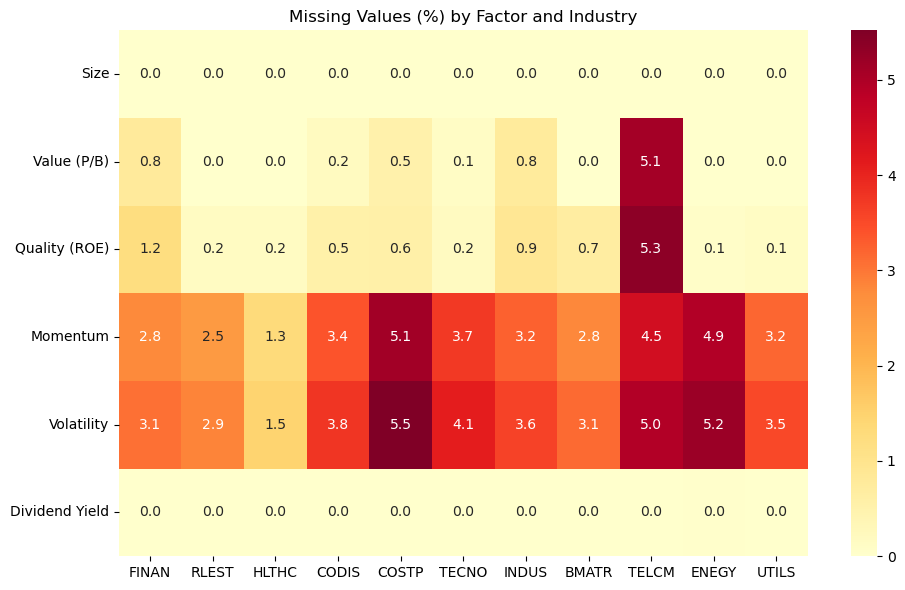

In [4]:
missing_df = pd.DataFrame(info['missing_pct'])
missing_df.columns = [FACTOR_NAMES.get(c, c) for c in missing_df.columns]
print(missing_df.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(missing_df.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Missing Values (%) by Factor and Industry')
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figures/missing_values_heatmap.pdf')
plt.show()

## 4. Stock Counts per Industry-Month

Average stocks per industry-month:
industry
BMATR    36.0
CODIS    45.4
COSTP    36.4
ENEGY    29.5
FINAN    87.6
HLTHC    13.5
INDUS    44.4
RLEST    13.6
TECNO    39.2
TELCM    22.4
UTILS    18.7

Total average per month: 387


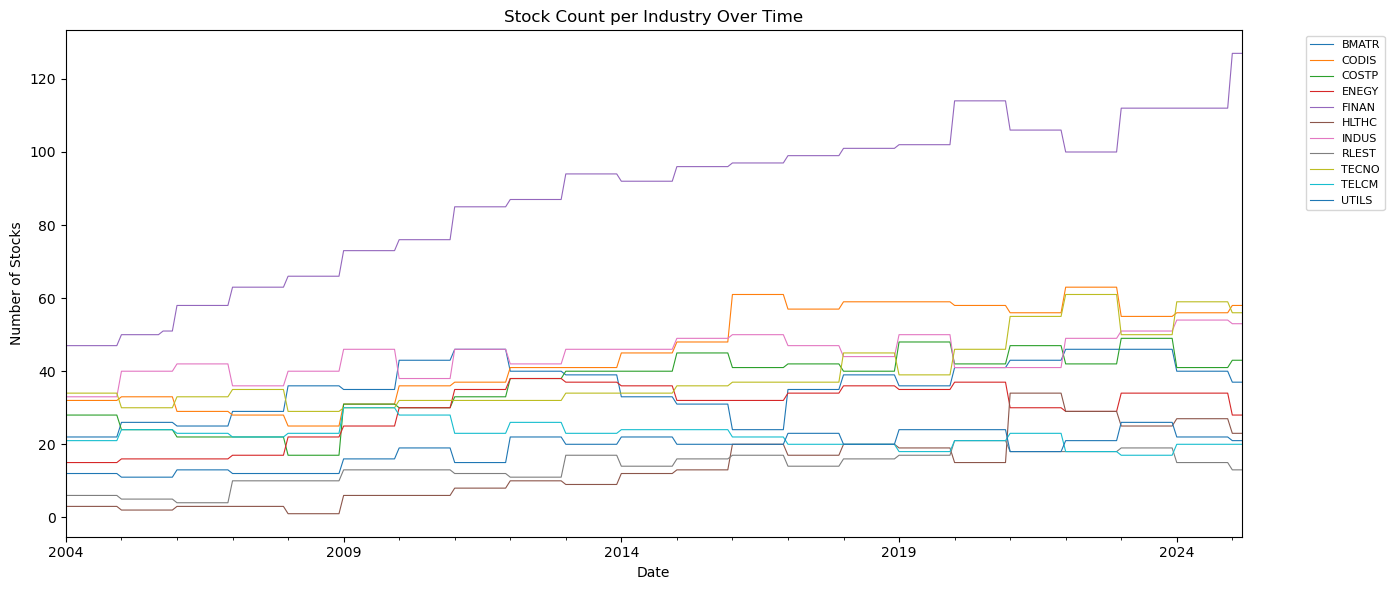

In [5]:
df_valid = df.dropna(subset=['industry'])
counts = df_valid.groupby(['ym', 'industry'])['ric'].nunique().unstack(fill_value=0)

print('Average stocks per industry-month:')
print(counts.mean().round(1).to_string())
print(f'\nTotal average per month: {counts.sum(axis=1).mean():.0f}')

fig, ax = plt.subplots(figsize=(14, 6))
counts.plot(ax=ax, linewidth=0.8)
ax.set_ylabel('Number of Stocks')
ax.set_xlabel('Date')
ax.set_title('Stock Count per Industry Over Time')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figures/stock_counts_by_industry.pdf')
plt.show()

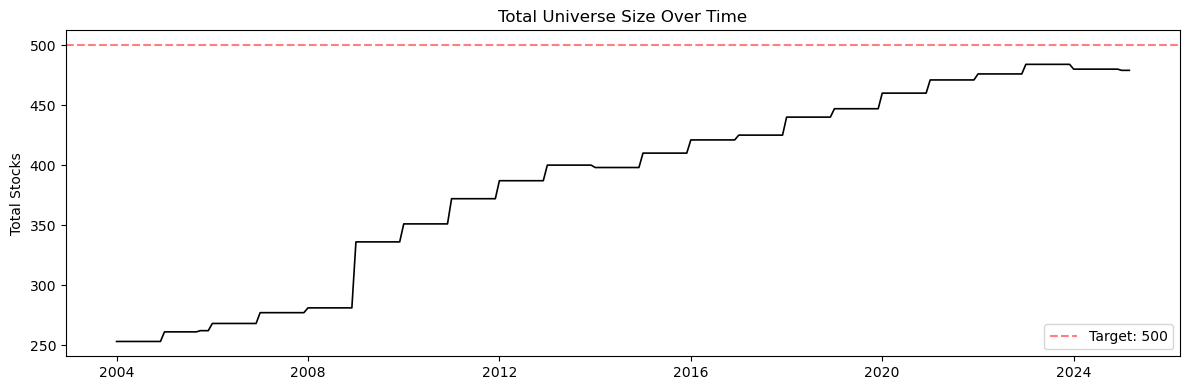

In [6]:
total_stocks = counts.sum(axis=1)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(total_stocks.index, total_stocks.values, color='black', linewidth=1.2)
ax.set_ylabel('Total Stocks')
ax.set_title('Total Universe Size Over Time')
ax.axhline(500, color='red', linestyle='--', alpha=0.5, label='Target: 500')
ax.legend()
fig.tight_layout()
plt.show()

## 5. Factor Distributions

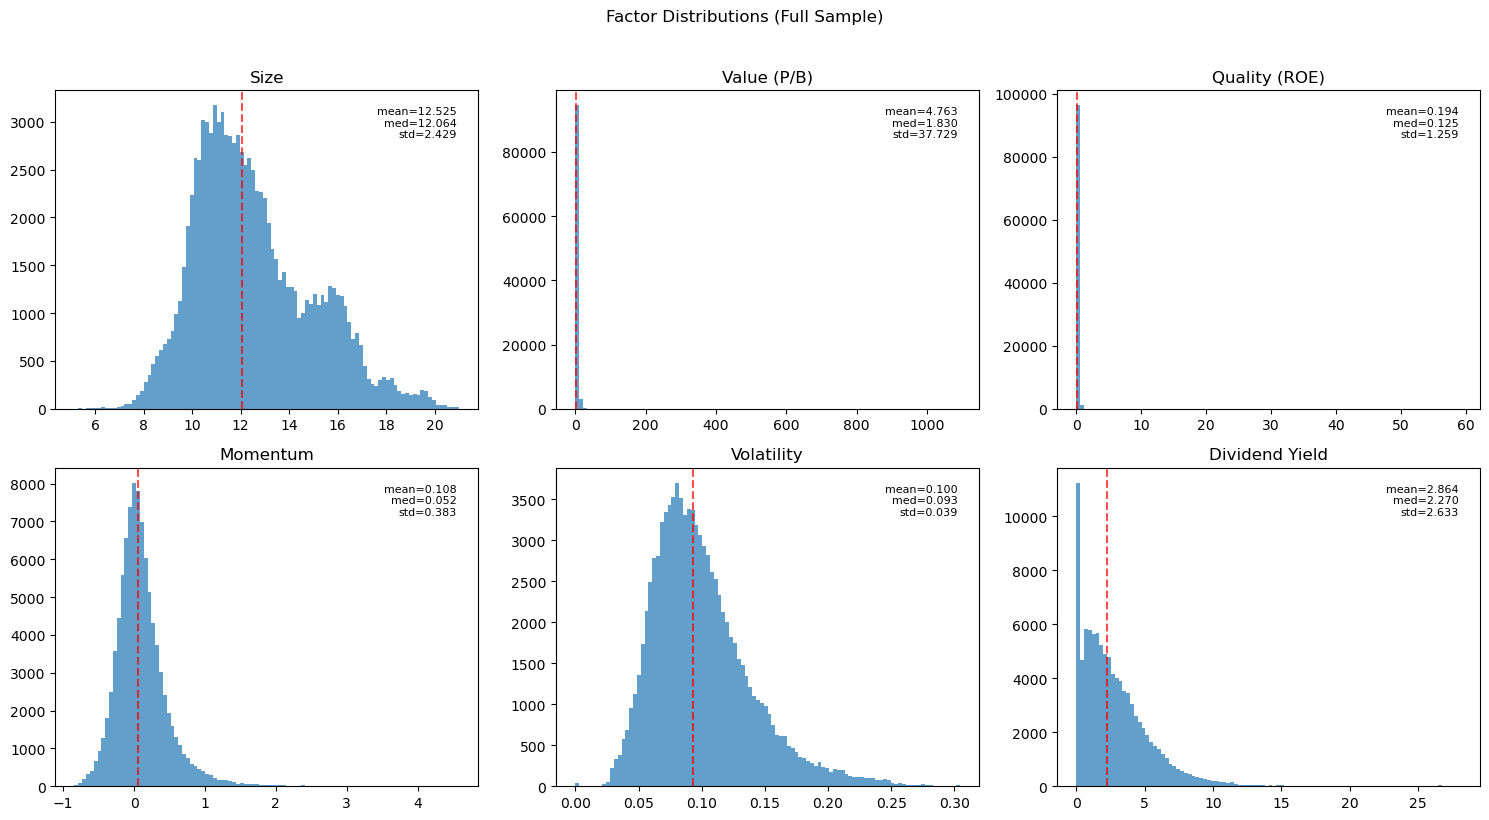

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, factor in zip(axes.flat, FACTOR_COLUMNS):
    data = df[factor].dropna()
    ax.hist(data, bins=100, edgecolor='none', alpha=0.7)
    ax.set_title(FACTOR_NAMES[factor])
    ax.axvline(data.median(), color='red', linestyle='--', alpha=0.7)
    stats_text = f'mean={data.mean():.3f}\nmed={data.median():.3f}\nstd={data.std():.3f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right', fontsize=8)

fig.suptitle('Factor Distributions (Full Sample)', y=1.02)
fig.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figures/factor_distributions.pdf')
plt.show()

## 6. Return Distributions

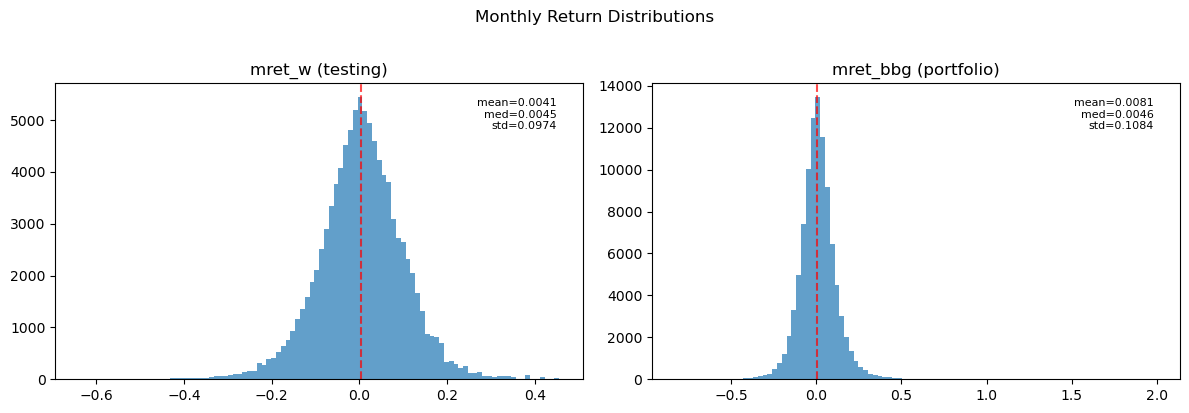

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes, [RETURN_COL_TESTING, RETURN_COL_PORTFOLIO],
                          ['mret_w (testing)', 'mret_bbg (portfolio)']):
    data = df[col].dropna()
    ax.hist(data, bins=100, edgecolor='none', alpha=0.7)
    ax.set_title(f'{label}')
    ax.axvline(data.median(), color='red', linestyle='--', alpha=0.7)
    stats_text = f'mean={data.mean():.4f}\nmed={data.median():.4f}\nstd={data.std():.4f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right', fontsize=8)

fig.suptitle('Monthly Return Distributions', y=1.02)
fig.tight_layout()
plt.show()

## 7. Benchmark and EEM Returns

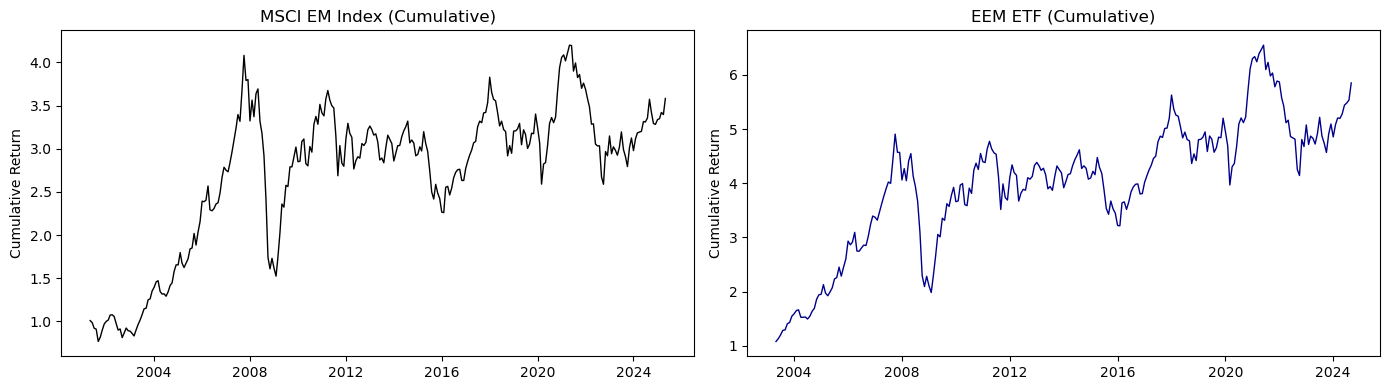

Benchmark: mean=0.0062, std=0.0589, Sharpe=0.36
EEM: mean=0.0087, std=0.0589, Sharpe=0.51


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cum_bench = (1 + benchmark).cumprod()
axes[0].plot(cum_bench.index, cum_bench.values, color='black', linewidth=1)
axes[0].set_title('MSCI EM Index (Cumulative)')
axes[0].set_ylabel('Cumulative Return')

cum_eem = (1 + eem).cumprod()
axes[1].plot(cum_eem.index, cum_eem.values, color='darkblue', linewidth=1)
axes[1].set_title('EEM ETF (Cumulative)')
axes[1].set_ylabel('Cumulative Return')

fig.tight_layout()
plt.show()

print(f'Benchmark: mean={benchmark.mean():.4f}, std={benchmark.std():.4f}, '
      f'Sharpe={benchmark.mean()/benchmark.std()*np.sqrt(12):.2f}')
print(f'EEM: mean={eem.mean():.4f}, std={eem.std():.4f}, '
      f'Sharpe={eem.mean()/eem.std()*np.sqrt(12):.2f}')

## 8. Country Distribution

Number of countries: 36

Top 15 countries by unique stock count:
country
CHINA                 191
SOUTH KOREA           115
INDIA                 107
TAIWAN                 96
BRAZIL                 60
HONG KONG              46
SOUTH AFRICA           38
THAILAND               32
MALAYSIA               28
SAUDI ARABIA           27
INDONESIA              26
TURKEY                 25
MEXICO                 21
PHILIPPINES            16
RUSSIAN FEDERATION     16


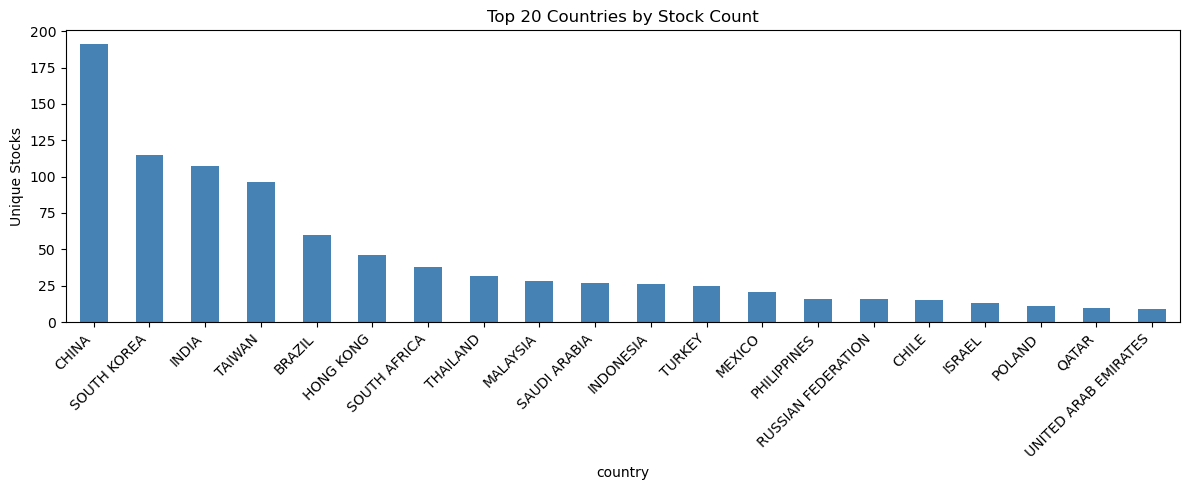

In [10]:
country_counts = df_valid.groupby('country')['ric'].nunique().sort_values(ascending=False)
print(f'Number of countries: {len(country_counts)}')
print('\nTop 15 countries by unique stock count:')
print(country_counts.head(15).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
country_counts.head(20).plot.bar(ax=ax, color='steelblue', edgecolor='none')
ax.set_ylabel('Unique Stocks')
ax.set_title('Top 20 Countries by Stock Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
plt.show()

## 9. Summary

Key findings from data validation:
- Data spans 2004-01 to 2025-03 with ~500 stocks per month across 11 industries
- Missing values are low (<4% for momentum and volatility, <1% for others)
- HLTHC and RLEST are small industries (~14 stocks/month) -- use tercile instead of quintile
- FINAN is the largest industry (~88 stocks/month)
- Benchmark (MSCI EM) and EEM data available for the full period